In [1]:
%reload_ext autoreload
%autoreload 2
import sys

sys.path.append("../../..")

In [2]:
import pandas as pd

from tqdm import tqdm
from pathlib import Path

from ltr_utility.dataset import load_query_similarity, load_by_query_dataset, DatasetName
from ltr_utility.model_selection import evaluate, show_distr_conf, custom_train

from experiments.wrappers import *

In [3]:
base_path = Path("../../../datasets")
base_result = Path("results")
base_result.mkdir(parents=True, exist_ok=True)

In [4]:
eval_at = [1, 2, 3, 4, 6, 8, 10, 12, 15, 20, 25]
hold_out = (0.5, 0.2, 0.3)
iqr_trim = None  #(25, 75)
query_groups = load_query_similarity(Path("../FINDHR/results"))

In [5]:
train, valid, test, train_valid = load_by_query_dataset(base_path, DatasetName.FINDHRLIST, hold_out=hold_out)

---- FINDHR LIST loaded ----
Filtered out 0 queries with fewer than 10 documents.
---- discard_minority_groups 10 queries ----
---- Get first 100 queries ----
---- max_item 400 -(determistic!) ----
---- Update the listwise ranking target  ----
---- Holdout (0.5, 0.2, 0.3) - (determistic!) ----


# LambdaMART

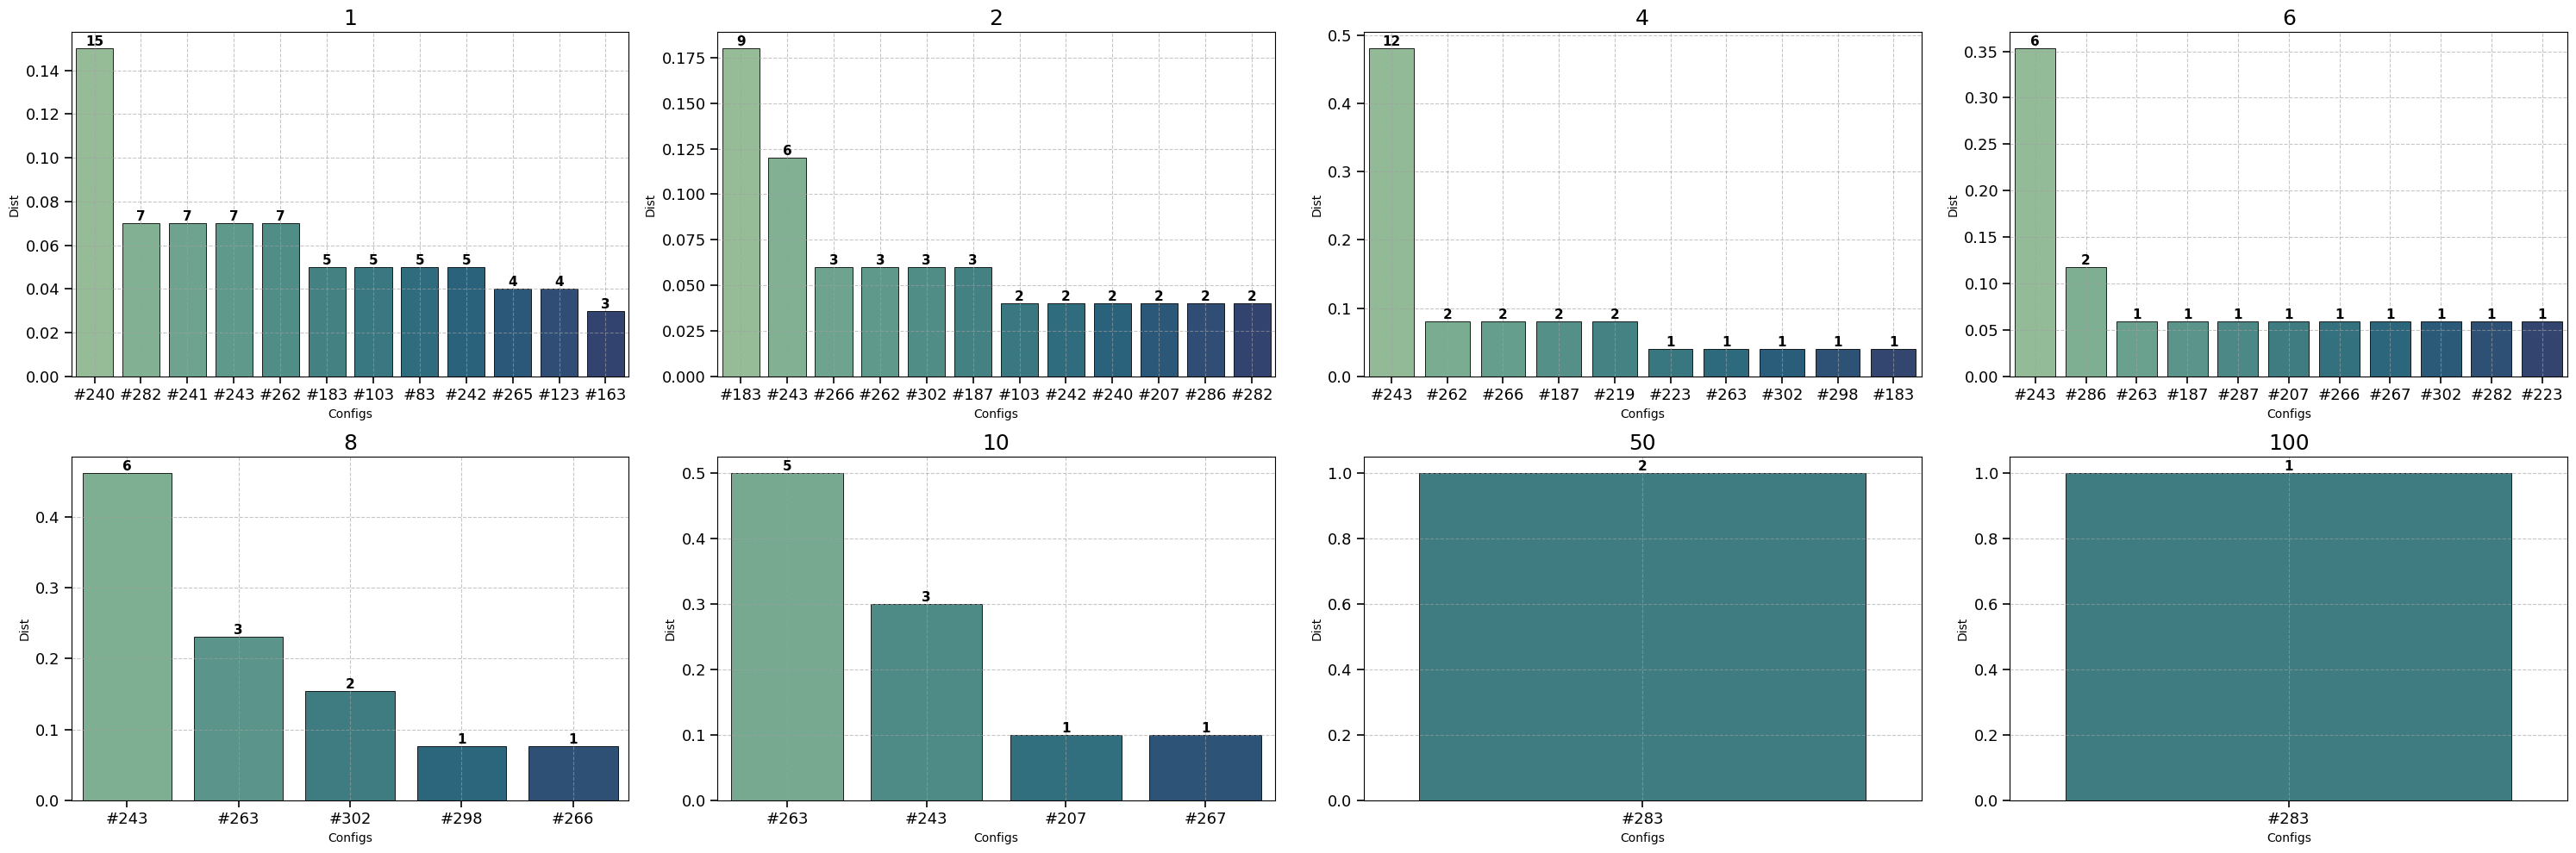

In [7]:
lm_ms = pd.read_json(base_result / "lm_query_model_selection.json")
lm_conf_dist = show_distr_conf(lm_ms)

In [7]:
lm_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:240, 2:183, 4:243, 6:243, 8:243, 10:263, 50:233, 100:283},
    "lm_query_model_selection.json",
    lm_ms,
    "LambdaMART",
    WrapperLGBMRanker
)

Training with one-shot mode (dict params).


Training: 100%|██████████| 100/100 [00:03<00:00, 28.00it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 50/50 [00:02<00:00, 18.08it/s]


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 10/10 [00:02<00:00,  4.76it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 2/2 [00:02<00:00,  1.28s/it]


Training with one-shot mode (dict params).


Training: 100%|██████████| 1/1 [00:02<00:00,  2.54s/it]


# KNN

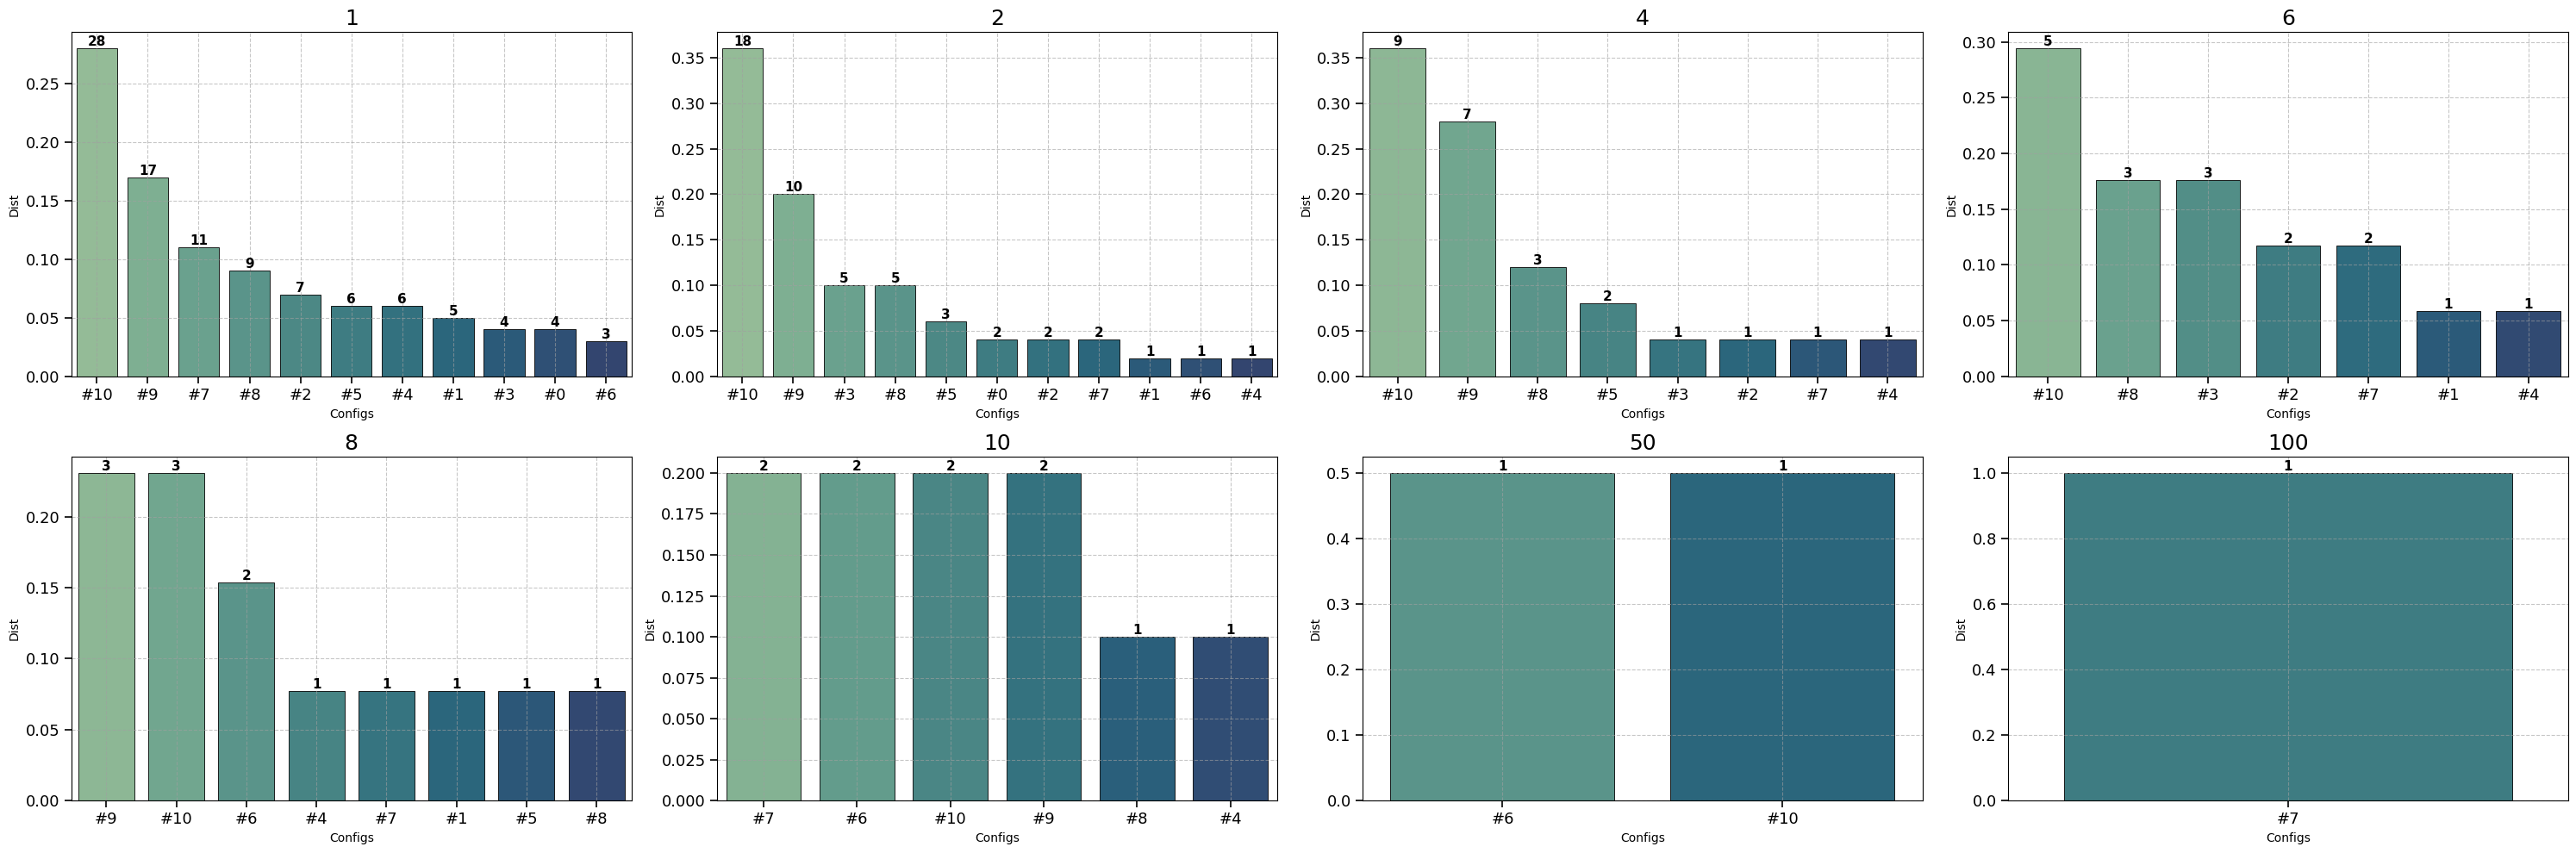

In [8]:
knn_ms = pd.read_json(base_result / "knn_query_model_selection.json")
knn_conf_dist = show_distr_conf(knn_ms)

In [ ]:
knn_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:10, 2:10, 4:10, 6:10, 8:9, 10:7, 50:6, 100:7},
    "knn_query_model_selection.json",
    knn_ms,
    "KNN Regressor",
    WrapperKNN
)

# RuleTreeRank

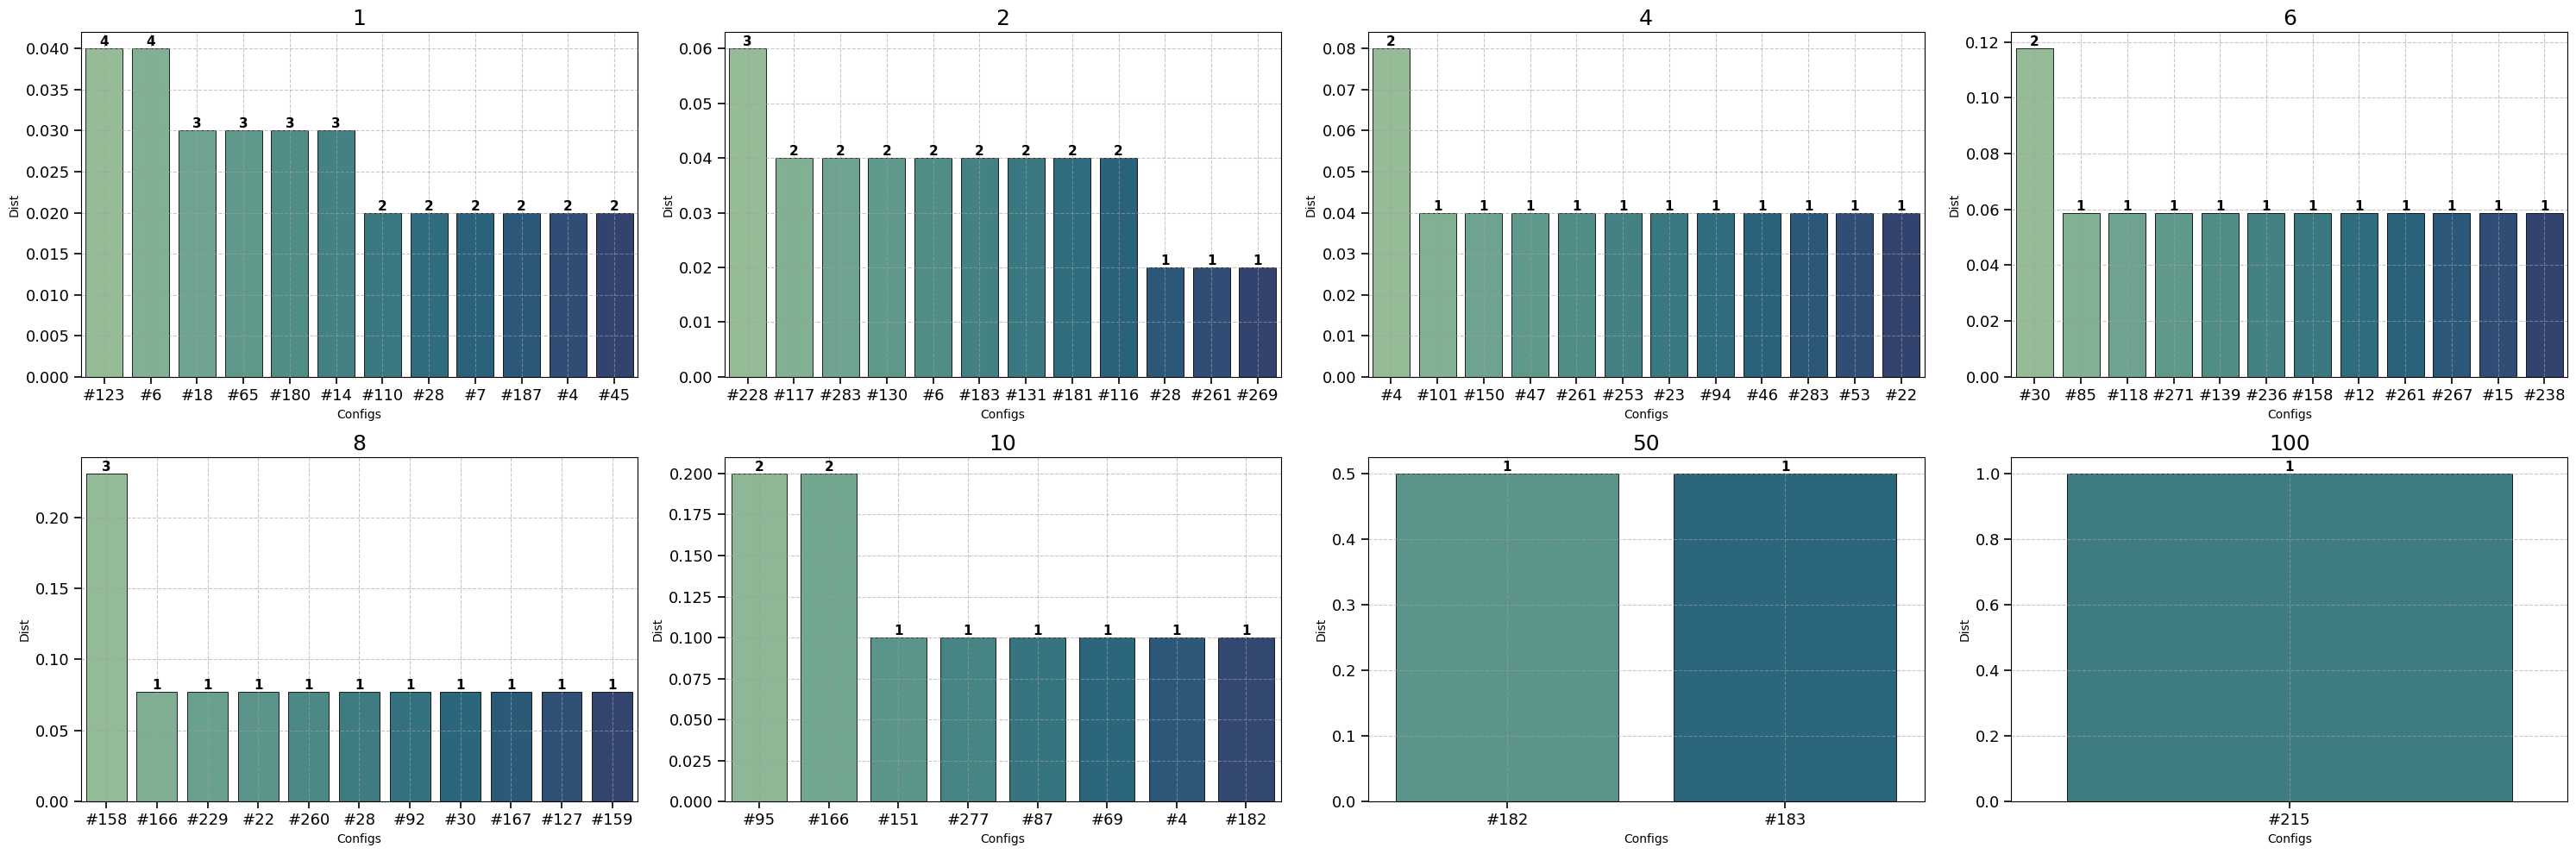

In [9]:
rtr_ms = pd.read_json(base_result / "rtr_query_model_selection.json")
rtr_conf_dist = show_distr_conf(rtr_ms)

In [16]:
rtr_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:123, 2:228, 4:4, 6:30, 8:158, 10:95, 50:182, 100:215},
    "rtr_query_model_selection.json",
    rtr_ms,
    "RuleTreeRank",
    WrapperRTR,
    rtr=True
)

Training: 100%|██████████| 13/13 [00:17<00:00,  1.32s/it]


Eval
10
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:13<00:00,  1.39s/it]


Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 2/2 [01:51<00:00, 55.67s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 1/1 [10:00<00:00, 600.59s/it]


Eval


# Mixed RuleTreeRank

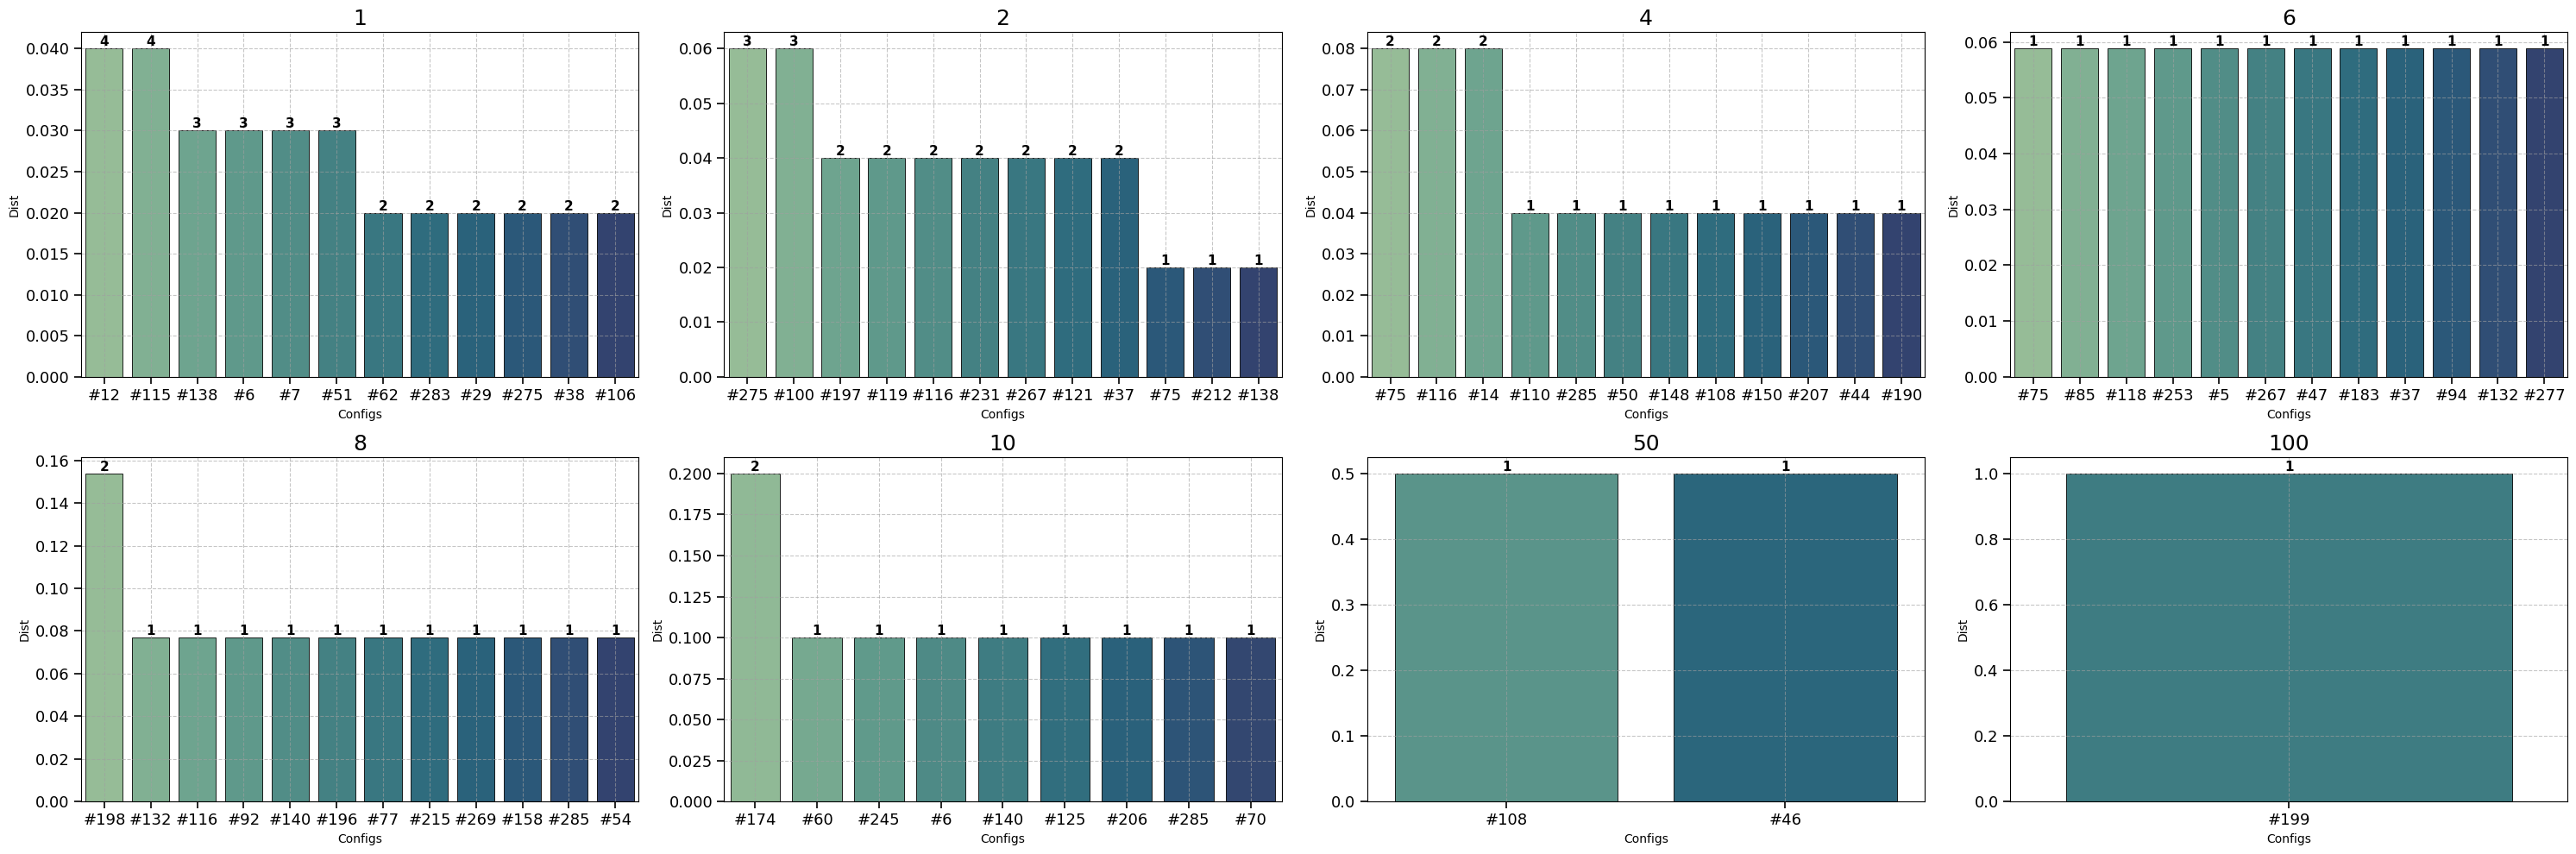

In [10]:
mix_rtr_ms = pd.read_json(base_result / "mix_rtr_query_model_selection.json")
mix_rtr_conf_dist = show_distr_conf(mix_rtr_ms)

In [15]:
mix_rtr_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:12, 2:275, 4:75, 6:75, 8:198, 10:174, 50:108, 100:199},
    "mix_rtr_query_model_selection.json",
    mix_rtr_ms,
    "Mix-RuleTreeRank",
    WrapperMixRTR,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 100/100 [00:38<00:00,  2.58it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 50/50 [00:14<00:00,  3.39it/s]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 2/2 [00:11<00:00,  5.71s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 1/1 [02:01<00:00, 121.60s/it]


Eval


# KNN(PDT)

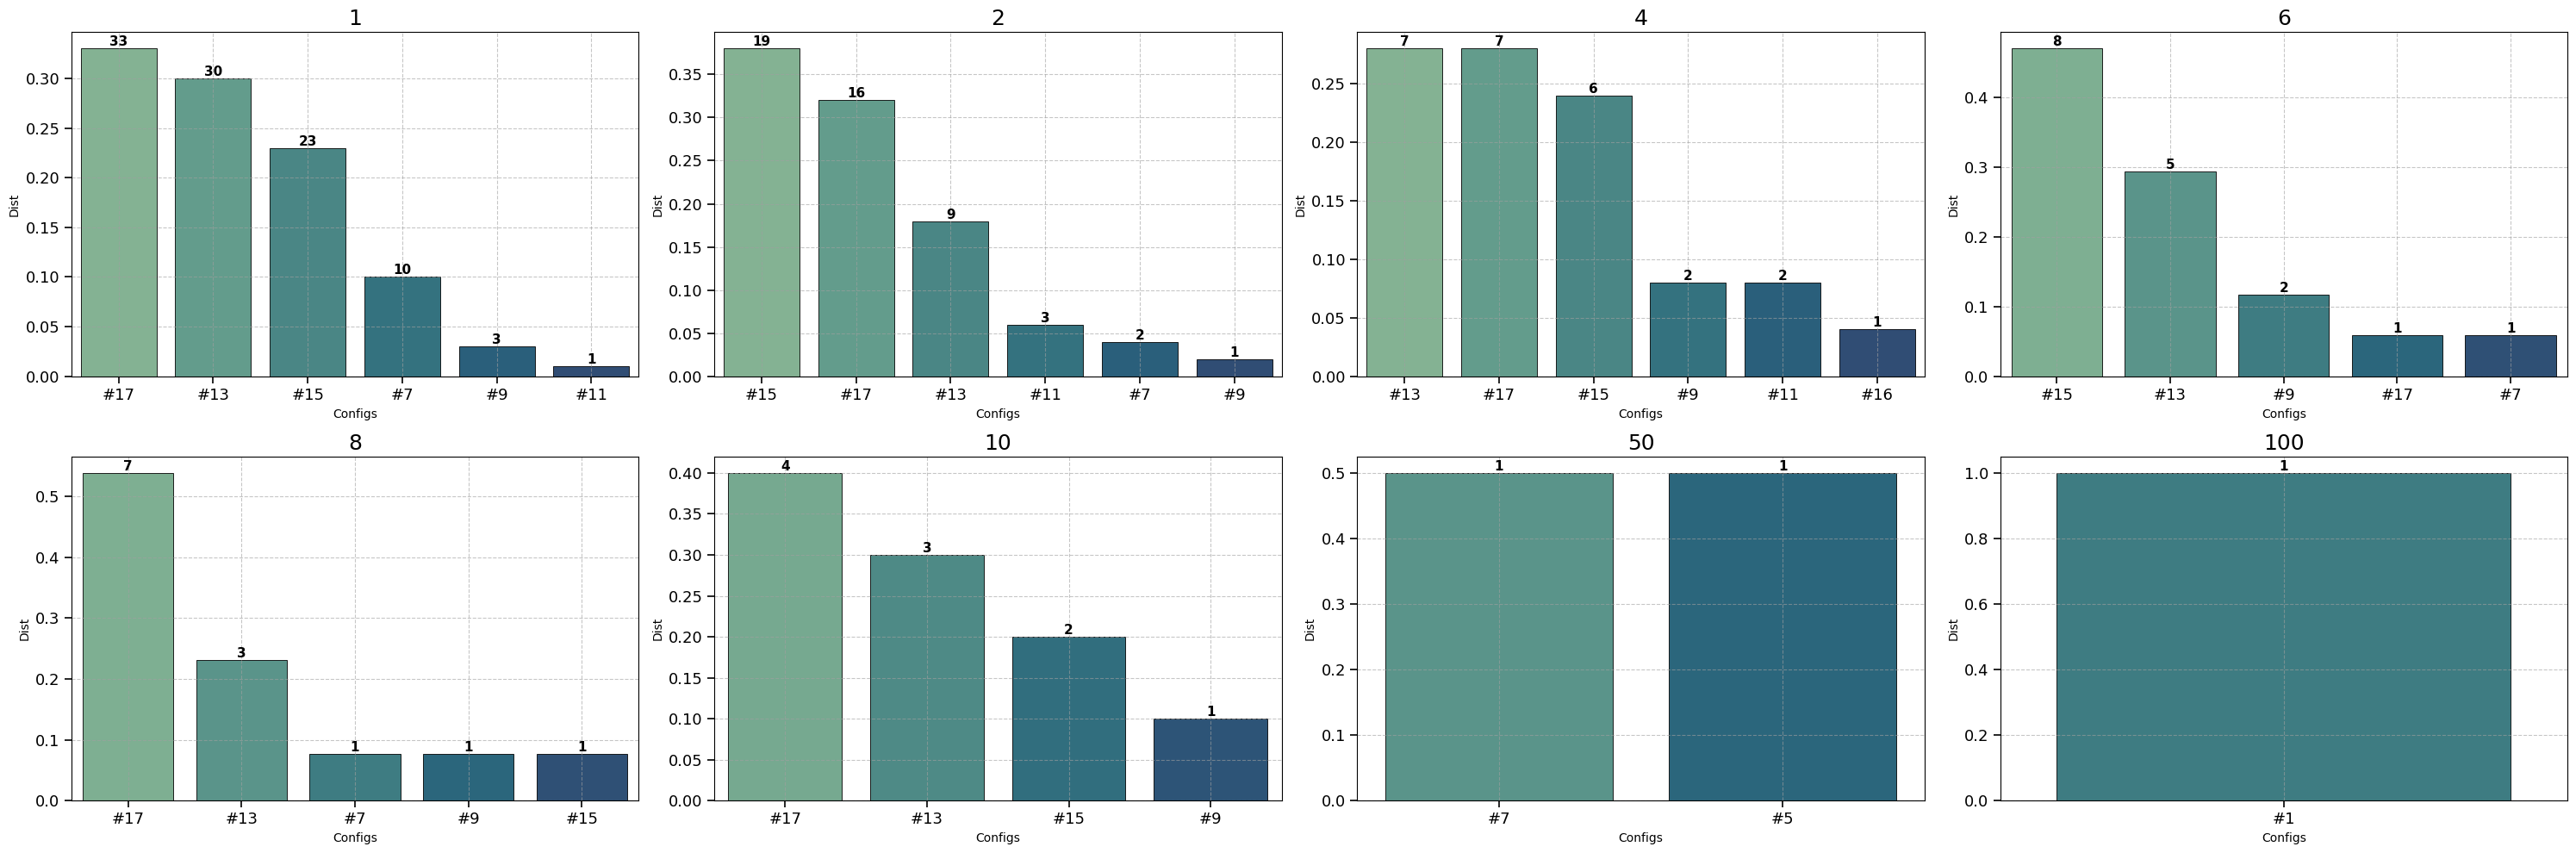

In [16]:
knn_pdt_ms = pd.read_json(base_result / "knn_pdt_query_model_selection.json")
knn_pdt_conf_dist = show_distr_conf(knn_pdt_ms)

In [17]:
knn_pdt_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:17, 2:15, 4:13, 6:15, 8:17, 10:17, 50:7, 100:1},
    "knn_pdt_query_model_selection.json",
    knn_pdt_ms,
    "KNNwPDT",
    WrapperKNNPDT,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 100/100 [00:19<00:00,  5.06it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 50/50 [00:39<00:00,  1.27it/s]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 2/2 [19:53<00:00, 596.70s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 1/1 [26:16<00:00, 1576.16s/it]


Eval


# Random ranker

In [22]:
from ltr_utility.model_selection.retrain import retrain_evaluate

random_result = retrain_evaluate(
    train_valid=train_valid,
    test=test,
    configs={i: (None, {}) for i in [1, 2, 4, 6, 8, 10, 50, 100]},
    model=RandomRanker, name="RandomRanker")

Training with one-shot mode (dict params).


Training: 100%|██████████| 100/100 [00:00<00:00, 7310.84it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 50/50 [00:00<00:00, 7686.38it/s]


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 10/10 [00:00<00:00, 4744.15it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 2/2 [00:00<00:00, 1746.54it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 1/1 [00:00<00:00, 941.69it/s]


# Eval results

In [ ]:
df_result = pd.concat([
    knn_pdt_result,
    knn_result,
    lm_result,
    mix_rtr_result,
    rtr_result,
    random_result,
], axis=0)


In [24]:
pd.concat([
    results,
    pd.read_json(base_result / "ilmart_query_model_selection.json"),
    pd.read_json(base_result / "listnet_query_model_selection.json"),
], axis=0).to_json(base_result / "FINDHRLIST_result.json", orient="records")

In [19]:
# Result for bloxplot
# results = []
# df_result = pd.concat([mix_rtr_result, knn_pdt_result], axis=0)
# for _, row in tqdm(df_result.iterrows(), total=len(mix_rtr_result)):
#     for k in eval_at:
#         res = evaluate(row["pred_test"], test.y, test.group_count, k=k,
#                        weight=False, aggregated=False)
#         results.append((row["model"], "test", row["qxm"], k, res))
#
# results = pd.DataFrame(results, columns=["model", "fold", "qxm", "k", "ndcg_s"])
# results.to_csv("FINDHRLIST_noagg.csv")

100%|██████████| 24/24 [00:08<00:00,  2.96it/s]
